In [1]:
!pip -q install google-generativeai

In [2]:
import google.generativeai as genai
from google.colab import userdata

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [3]:
from pathlib import Path
from datetime import datetime

OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

In [4]:
api_key = userdata.get("GEMINI_API_KEY")
if api_key is None:
    raise ValueError("GEMINI_API_KEY not found in Colab Secrets")

genai.configure(api_key=api_key)

print("Gemini configured successfully")

Gemini configured successfully


In [5]:
import google.generativeai as genai

models = list(genai.list_models())

# Print models that support text generation
for m in models:
    methods = getattr(m, "supported_generation_methods", [])
    if "generateContent" in methods:
        print(m.name, methods)

models/gemini-2.5-flash ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.5-pro ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-001 ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-exp-image-generation ['generateContent', 'countTokens', 'bidiGenerateContent']
models/gemini-2.0-flash-lite-001 ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-lite ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.5-flash-preview-tts ['countTokens', 'generateContent']
models/gemini-2.5-pro-preview-tts ['countTokens', 'generateContent', 'batchGenerateContent']
models/gemma-3-1b-it ['generateContent', 'countTokens']
models/gemma-3-4b-it ['ge

In [8]:
model = genai.GenerativeModel("models/gemini-pro-latest")
print("Using model: models/gemini-pro-latest")

Using model: models/gemini-pro-latest


In [9]:
text_prompt = """
You are a friendly deep learning tutor.

1. Ask me 5 short questions to assess my understanding of:
   - tensors
   - gradients
   - backpropagation
   - loss functions
   - overfitting
2. After each question, give a small hint.
3. End with a 5-point personalized study plan for deep learning.
"""

response = model.generate_content(text_prompt)

chat_text = response.text
print(chat_text)

(OUT / "text_chat.md").write_text(chat_text, encoding="utf-8")
print("Saved outputs/text_chat.md")

Hello there! I'm so excited to help you on your deep learning journey. To figure out where we should start, I've prepared a quick little quiz. Don't worry about getting everything perfectly right—this is just to see what you already know!

Here are 5 short questions. Feel free to answer them in your own words:

**1. Tensors**
What exactly is a tensor, and how does it relate to things you might already know, like scalars, vectors, and matrices?
*💡 Hint: Think about how we organize data using dimensions or "axes."*

**2. Gradients**
In simple terms, what does a gradient tell us about a neural network's parameters?
*💡 Hint: Imagine you are blindfolded on a hilly terrain trying to walk to the lowest point. What information do you need about the ground right under your feet?*

**3. Backpropagation**
How does the backpropagation algorithm work to improve a neural network? 
*💡 Hint: It relies on a very famous rule from calculus (starts with "c") to pass information backwards from the output t

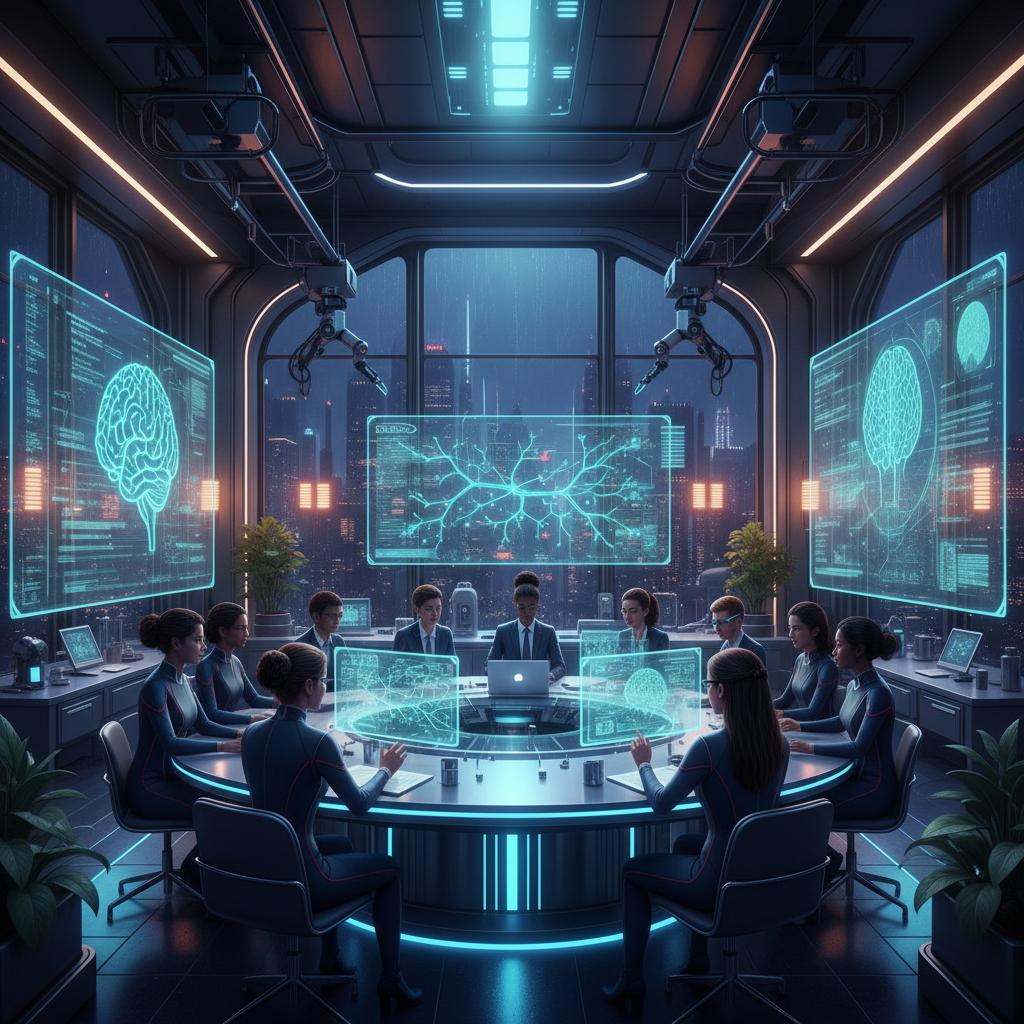

Saved image to outputs/generated_image_20260306_212000.png


In [11]:
image_prompt = """
Create a visually striking futuristic AI university lab at night,
students collaborating around glowing screens,
neural network diagrams on transparent displays,
cinematic lighting, highly detailed, modern, vibrant.
"""

image_model = genai.GenerativeModel("models/gemini-2.5-flash-image")

response = image_model.generate_content(image_prompt)

from PIL import Image
import io
from IPython.display import display

for part in response.candidates[0].content.parts:
    if hasattr(part, "inline_data") and part.inline_data:
        image_bytes = part.inline_data.data
        img = Image.open(io.BytesIO(image_bytes))
        display(img)

        img_path = OUT / f"generated_image_{timestamp}.png"
        img.save(img_path)

        print(f"Saved image to {img_path}")

In [12]:
from google.colab import files
uploaded = files.upload()

Saving Business Conference.png to Business Conference.png


In [13]:
from pathlib import Path

# find the uploaded image
input_image = None
for ext in ["*.png", "*.jpg", "*.jpeg", "*.webp"]:
    matches = list(Path(".").glob(ext))
    if matches:
        input_image = matches[0]
        break

if input_image is None:
    raise FileNotFoundError("No uploaded image found. Please upload an image first.")

print("Using image:", input_image)

Using image: Business Conference.png


In [14]:
uploaded_file = genai.upload_file(path=str(input_image))

vision_model = genai.GenerativeModel("models/gemini-2.5-flash")

analysis_prompt = """
Analyze this image in a useful and interesting way.

Please provide:
1. A short description of what is visible
2. Five notable details
3. A short creative caption
4. Three interesting insights or observations
"""

response = vision_model.generate_content([analysis_prompt, uploaded_file])

analysis_text = response.text
print(analysis_text)

# save text output
(OUT / "image_analysis.md").write_text(analysis_text, encoding="utf-8")

# save a copy of the input image into outputs
saved_input = OUT / f"input_image_{timestamp}{input_image.suffix}"
saved_input.write_bytes(Path(input_image).read_bytes())

print(f"Saved analysis to {OUT / 'image_analysis.md'}")
print(f"Saved input image copy to {saved_input}")

Here's an analysis of the image:

---

### 1. Short Description of What is Visible
The image depicts a professional conference or presentation taking place in a darkened auditorium. A male speaker stands at a podium, gesturing towards a large screen displaying various charts, graphs, and a map. To his right, a panel of three individuals (one woman, two men) sits at a table with microphones and water. A sizeable audience is seated in rows, facing the stage and screen.

### 2. Five Notable Details
1.  **The Presentation Screen Content:** The screen features a diverse set of visuals including pie charts, overlapping circles (possibly a Venn diagram or a data comparison), bar graphs, and prominently, a blue map resembling an archipelago or a coastal region (potentially Greece or a similar area). This suggests a multi-faceted topic involving both statistical and geographical data.
2.  **The Panel of Experts/Guests:** The three individuals seated at the table with microphones indicate that t

In [ ]:
from google.colab import drive
drive.mount('/content/drive')